# CodeAlpha — Iris Flower Classification

This project classifies Iris flowers into **Setosa, Versicolor, and Virginica** using measurements of the flowers and a machine-learning classification model.


## 1. Import Libraries


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


## 2. Load the Iris Dataset

Scikit-learn provides the Iris dataset directly, so a separate download is not required for this implementation.


In [22]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='target')

df = X.copy()
df['species'] = y.map(dict(enumerate(iris.target_names)))

print('Dataset shape:', df.shape)
display(df.head())


Dataset shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Explore the Data


In [23]:
print(df.info())
display(df.describe())
print('\nMissing values:\n', df.isnull().sum())
print('\nClass distribution:\n', df['species'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Class distribution:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 4. Visualize the Classes


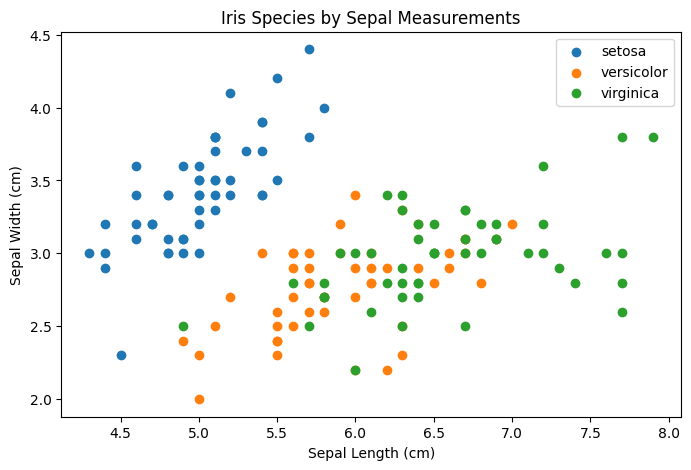

In [24]:
plt.figure(figsize=(8, 5))
for species in iris.target_names:
    subset = df[df['species'] == species]
    plt.scatter(subset['sepal length (cm)'], subset['sepal width (cm)'], label=species)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris Species by Sepal Measurements')
plt.legend()
plt.show()


## 5. Split the Data

The data is divided into training and testing sets. The model learns from the training set and is evaluated on unseen test data.


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))


Training samples: 120
Testing samples: 30


## 6. Standardize the Features


In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 7. Train the Classification Model

A K-Nearest Neighbors (KNN) classifier is used here because it is simple and suitable for this small classification dataset.


In [27]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


## 8. Evaluate the Model


In [31]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2%}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## 9. Confusion Matrix


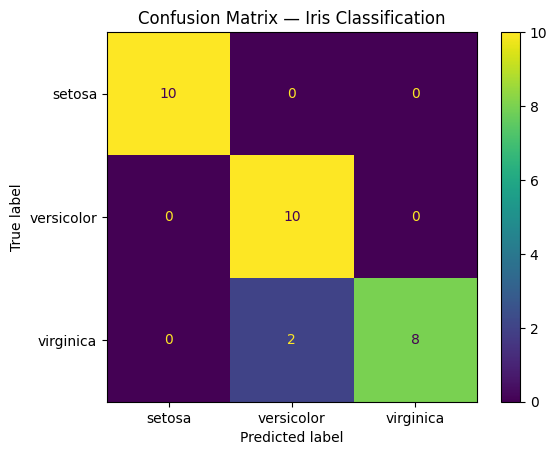

In [29]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title('Confusion Matrix — Iris Classification')
plt.show()


## 10. Example Prediction


In [30]:
sample = [[5.1, 3.5, 1.4, 0.2]]
sample_scaled = scaler.transform(sample)
prediction = model.predict(sample_scaled)[0]
print('Predicted species:', iris.target_names[prediction])


Predicted species: setosa


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Conclusion

The trained KNN model uses four Iris flower measurements to classify the flower species. Model performance is evaluated on unseen test data using accuracy, a classification report, and a confusion matrix. The project demonstrates a basic end-to-end machine-learning classification workflow.
